# 📌 Pandas DataFrame: Deep Dive for Data Science
A DataFrame is a 2D labeled data structure in Pandas, similar to an Excel sheet or a SQL table.

# 1. Creating a DataFrame
# Creating DataFrame in Pandas

| Method | Syntax |
|--------|-------------|
| **From Dictionary** | `df = pd.DataFrame(data)` |
| **From List of Lists** | `df = pd.DataFrame(data, columns=column_names)` |
| **From List of Dictionaries** | `df = pd.DataFrame(data)` |
| **From NumPy Array** | `df = pd.DataFrame(np_array, columns=column_names)` |
| **From Tuple of Lists** | `df = pd.DataFrame(list(zip(*data)), columns=column_names)` |
| **From CSV File** | `df = pd.read_csv("file.csv")` |
| **From Excel File** | `df = pd.read_excel("file.xlsx")` |
| **From Dictionary of Series** | `df = pd.DataFrame({"col1": pd.Series(data), "col2": pd.Series(data)})` |
| **From JSON Data** | `df = pd.read_json(json_data)` |
| **Creating an Empty DataFrame** | `df = pd.DataFrame(columns=column_names)` |


# 📌 1. Creating DataFrame from a Dictionary ✅

In [1]:

import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Salary": [50000, 60000, 70000]
}

df = pd.DataFrame(data)
print(df)


      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


# 📌 2. Creating DataFrame from a List of Lists
✅ Useful when data is structured like a table.

In [2]:
data = [
    ["Alice", 25, 50000],
    ["Bob", 30, 60000],
    ["Charlie", 35, 70000]
]

df = pd.DataFrame(data, columns=["Name", "Age", "Salary"])
print(df)


      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


# 📌 3. Creating DataFrame from a List of Dictionaries
✅ Useful when data is in dictionary format, and keys become column names.


In [4]:
data = [
    {"Name": "Alice", "Age": 25, "Salary": 50000},
    {"Name": "Bob", "Age": 30, "Salary": 60000},
    {"Name": "Charlie", "Age": 35, "Salary": 70000}
]

df = pd.DataFrame(data)
print(df)


      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


# 📌 4. Creating DataFrame from NumPy Arrays 
✅ Best when working with numerical or array-based data.

In [6]:
import numpy as np

data = np.array([
    ["Alice", 25, 50000],
    ["Bob", 30, 60000],
    ["Charlie", 35, 70000]
])

df = pd.DataFrame(data, columns=["Name", "Age", "Salary"])
print(df)


      Name Age Salary
0    Alice  25  50000
1      Bob  30  60000
2  Charlie  35  70000


# 📌 5. Creating DataFrame from a Tuple of Lists
✅ Useful when dealing with multiple lists stored in a tuple.

In [7]:
data = (["Alice", "Bob", "Charlie"], [25, 30, 35], [50000, 60000, 70000])

df = pd.DataFrame(list(zip(*data)), columns=["Name", "Age", "Salary"])
print(df)


      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


# 📌 6. Creating DataFrame from a CSV File
✅ Best when loading external datasets.


In [9]:
df = pd.read_csv("test_data.csv")  # Load data from CSV file
print(df)


      Name  Age  Salary
0    Alice   25   50000
1      Bob   30   60000
2  Charlie   35   70000


# 📌 7. Creating DataFrame from an Excel File
✅ Useful for structured spreadsheet data.

In [17]:
df = pd.read_excel("Inventory-Records-Sample-Data.xlsx")  # Load data from Excel
print(df)
print(df.columns)


    Unnamed: 0              Unnamed: 1                   Unnamed: 2  \
0          NaN       Excel Sample Data                          NaN   
1          NaN                     NaN                          NaN   
2          NaN  Inventory Records Data                          NaN   
3          NaN                     NaN                          NaN   
4          NaN              Product ID                 Product Name   
5          NaN                    P101                       Laptop   
6          NaN                    P102                      Monitor   
7          NaN                    P103                     Keyboard   
8          NaN                    P104                   Headphones   
9          NaN                    P105                   Smartphone   
10         NaN                    P106                       Tablet   
11         NaN                    P107                       Router   
12         NaN                    P108          External Hard Drive   
13    

# 📌 8. Creating DataFrame from a Dictionary of Series
✅ When you have individual Pandas Series for different columns.

In [18]:
data = {
    "Age": pd.Series([25, 30, 35], index=["Alice", "Bob", "Charlie"]),
    "Salary": pd.Series([50000, 60000, 70000], index=["Alice", "Bob", "Charlie"])
}

df = pd.DataFrame(data)
print(df)


         Age  Salary
Alice     25   50000
Bob       30   60000
Charlie   35   70000


# 📌 9. Creating DataFrame from JSON
✅ Best when working with JSON data (e.g., API responses).


In [19]:
data = '[{"Name": "Alice", "Age": 25, "Salary": 50000}, {"Name": "Bob", "Age": 30, "Salary": 60000}]'

df = pd.read_json(data)
print(df)


    Name  Age  Salary
0  Alice   25   50000
1    Bob   30   60000


# Example API Response for Stock Prices
Endpoint:
📌 GET /api/stock_prices?symbol=AAPL&start_date=2024-01-01&end_date=2024-01-10

In [30]:
import requests
import pandas as pd

# My free API key from Alpha Vantage
API_KEY = "6OO22XAMKI3BFXXT"
symbol = "AAPL"

# Construct API URL
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={symbol}&apikey={API_KEY}&outputsize=compact"

# Fetch API response
response = requests.get(url)
data = response.json()

# Extract stock data (dates as keys)
stock_data = data.get("Time Series (Daily)", {})
# Alpha Vantage returns data under "Time Series (Daily)", not "data".
# data stock_data  is a nested dictionary where dates are keys. We need to transform it into a DataFrame properly.
print(stock_data)
print("------------------------------------")
# Convert dictionary to Pandas DataFrame
df = pd.DataFrame.from_dict(stock_data, orient="index")

# Rename columns
df.columns = ["open", "high", "low", "close", "volume"]

# Convert columns to numeric
df = df.astype(float)

# Reset index and rename it to "date"
df.reset_index(inplace=True)
df.rename(columns={"index": "date"}, inplace=True)

# Display DataFrame
print(df.head())


{'2025-02-21': {'1. open': '245.9500', '2. high': '248.6900', '3. low': '245.2200', '4. close': '245.5500', '5. volume': '53197431'}, '2025-02-20': {'1. open': '244.9400', '2. high': '246.7800', '3. low': '244.2900', '4. close': '245.8300', '5. volume': '32316907'}, '2025-02-19': {'1. open': '244.6600', '2. high': '246.0100', '3. low': '243.1604', '4. close': '244.8700', '5. volume': '32204215'}, '2025-02-18': {'1. open': '244.1500', '2. high': '245.1800', '3. low': '241.8400', '4. close': '244.4700', '5. volume': '48822491'}, '2025-02-14': {'1. open': '241.2500', '2. high': '245.5500', '3. low': '240.9900', '4. close': '244.6000', '5. volume': '40896227'}, '2025-02-13': {'1. open': '236.9100', '2. high': '242.3399', '3. low': '235.5700', '4. close': '241.5300', '5. volume': '53614054'}, '2025-02-12': {'1. open': '231.2000', '2. high': '236.9600', '3. low': '230.6800', '4. close': '236.8700', '5. volume': '45243292'}, '2025-02-11': {'1. open': '228.2000', '2. high': '235.2300', '3. low

# 📌 10. Creating an Empty DataFrame
✅ Useful when defining a DataFrame before adding data dynamically.

In [20]:
df = pd.DataFrame(columns=["Name", "Age", "Salary"])
print(df)


Empty DataFrame
Columns: [Name, Age, Salary]
Index: []


#  Inspecting Data
# 📊 Summary Table of Pandas Inspection Methods  

| **Inspection Task**       | **Pandas Method**         |
|---------------------------|--------------------------|
| First few rows            | `df.head(n)`             |
| Last few rows             | `df.tail(n)`             |
| General info              | `df.info()`              |
| Summary statistics        | `df.describe()`          |
| Data types                | `df.dtypes`              |
| Shape of DataFrame        | `df.shape`               |
| Column names              | `df.columns`             |
| Missing values            | `df.isnull().sum()`      |
| Duplicate rows            | `df.duplicated().sum()`  |
| Unique values             | `df["col"].unique()`     |
| Count of unique values    | `df["col"].nunique()`    |


In [83]:
import pandas as pd
import numpy as np

# Sample DataFrame
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve", "Alice"],
    "Age": [25, 30, 35, np.nan, 40, 25],
    "City": ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix", "New York"],
    "Salary": [60000, 70000, 80000, 75000, np.nan, 60000],
}

df = pd.DataFrame(data)

# 1️⃣ Viewing First & Last Rows
print("First 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

# 2️⃣ General Dataset Information
print("\nDataset Info:")
df.info()

# 3️⃣ Summary Statistics
print("\nSummary Statistics:\n", df.describe())

# 4️⃣ Checking Data Types
print("\nData Types:\n", df.dtypes)

# 5️⃣ Shape & Column Names
print("\nShape of DataFrame:", df.shape)
print("\nColumn Names:", df.columns)

# 6️⃣ Checking Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# 7️⃣ Checking Duplicate Rows
print("\nDuplicate Rows Count:", df.duplicated().sum())
print("\nDuplicate Rows:\n", df[df.duplicated()])

# 8️⃣ Unique Values in a Column
print("\nUnique Cities:", df["City"].unique())
print("\nNumber of Unique Cities:", df["City"].nunique())


First 5 rows:
       Name   Age         City   Salary
0    Alice  25.0     New York  60000.0
1      Bob  30.0  Los Angeles  70000.0
2  Charlie  35.0      Chicago  80000.0
3    David   NaN      Houston  75000.0
4      Eve  40.0      Phoenix      NaN

Last 5 rows:
       Name   Age         City   Salary
1      Bob  30.0  Los Angeles  70000.0
2  Charlie  35.0      Chicago  80000.0
3    David   NaN      Houston  75000.0
4      Eve  40.0      Phoenix      NaN
5    Alice  25.0     New York  60000.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    6 non-null      object 
 1   Age     5 non-null      float64
 2   City    6 non-null      object 
 3   Salary  5 non-null      float64
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes

Summary Statistics:
              Age       Salary
count   5.000000      5.00000
mean   31.000000  69000.00

## 📌 Accessing Data in Pandas

| Method | Description | Example |
|--------|-------------|---------|
| `df["Column_Name"]` | Select a single column | `df["Country"]` |
| `df.Column_Name` | Alternative way to select a single column | `df.Country` |
| `df[["Column1", "Column2"]]` | Select multiple columns | `df[["Country", "Population"]]` |
| `df.loc[row_label]` | Select a row using label-based indexing | `df.loc[2]` |
| `df.loc[row_label, "Column_Name"]` | Select a specific value using a row label | `df.loc[2, "Country"]` |
| `df.loc[row_label, ["Column1", "Column2"]]` | Select multiple columns for a specific row | `df.loc[2, ["Country", "GDP"]]` |
| `df.iloc[row_position]` | Select a row using position-based indexing | `df.iloc[2]` |
| `df.iloc[row_position, column_position]` | Select a specific value using position-based indexing | `df.iloc[2, 1]` |
| `df[2:5]` | Select a range of rows (index slicing) | `df[2:5]` (Rows 2 to 4) |
| `df.loc[2:5]` | Select a range of rows using labels | `df.loc[2:5]` |
| `df.iloc[2:5]` | Select a range of rows using positions | `df.iloc[2:5]` |
| `df[df["Column_Name"] > value]` | Filter rows based on condition | `df[df["Population"] > 100]` |
| `df[(df["Column1"] > val1) & (df["Column2"] < val2)]` | Filter with multiple conditions | `df[(df["Population"] > 100) & (df["GDP"] > 3)]` |
| `df.at[row_label, "Column_Name"]` | Fast access to a single value (label-based) | `df.at[2, "Country"]` |
| `df.iat[row_position, column_position]` | Fast access to a single value (position-based) | `df.iat[2, 1]` |

---

This table neatly summarizes the **important methods for accessing data in Pandas**. 🚀 Let me know if you need any modifications! 😊  


In [33]:
df = pd.read_csv("large_world_cities.csv")
df.head()

,City,Country,Population,GDP_per_Capita,Latitude,Longitude,Continent
0,New York,USA,8419600,85000,40.7128,-74.0060,North America
1,Los Angeles,USA,3980400,79000,34.0522,-118.2437,North America
2,Chicago,USA,2716000,72000,41.8781,-87.6298,North America
3,Houston,USA,2328000,67000,29.7604,-95.3698,North America
4,Phoenix,USA,1690000,63000,33.4484,-112.0740,North America


In [40]:
import pandas as pd

# Load the dataset
file_path = "large_world_cities.csv"  # Ensure this file is in the same directory as this script
df = pd.read_csv(file_path)

# 1. Select a single column
country_column = df["Country"]
print("Single Column Selection:\n", country_column.head())

# 2. Alternative way to select a single column
country_column_alt = df.Country
print("Alternative Single Column Selection:\n", country_column_alt.head())

# 3. Select multiple columns
selected_columns = df[["Country", "Population"]]
print("Multiple Columns Selection:\n", selected_columns.head())

# 4. Select a row using label-based indexing
row_label_based = df.loc[2]
print("Row Selection using Label-based Indexing:\n", row_label_based)

# 5. Select a specific value using a row label
specific_value_label = df.loc[2, "Country"]
print("Specific Value using Label-based Indexing:\n", specific_value_label)

# 6. Select multiple columns for a specific row
multiple_columns_label = df.loc[2, ["Country", "GDP_per_Capita"]]
print("Multiple Columns Selection for a Row:\n", multiple_columns_label)

# 7. Select a row using position-based indexing
row_position_based = df.iloc[2]
print("Row Selection using Position-based Indexing:\n", row_position_based)

# 8. Select a specific value using position-based indexing
specific_value_position = df.iloc[2, 1]
print("Specific Value using Position-based Indexing:\n", specific_value_position)

# 9. Select a range of rows (index slicing)
row_range = df[2:5]
print("Range of Rows using Index Slicing:\n", row_range)

# 10. Select a range of rows using labels
row_range_label = df.loc[2:5]
print("Range of Rows using Labels:\n", row_range_label)

# 11. Select a range of rows using positions
row_range_position = df.iloc[2:5]
print("Range of Rows using Positions:\n", row_range_position)

# 12. Filter rows based on condition
population_greater_than_5m = df[df["Population"] > 5000000]
print("Filter Rows where Population > 5 Million:\n", population_greater_than_5m.head())

# 13. Filter with multiple conditions
high_population_high_gdp = df[(df["Population"] > 5000000) & (df["GDP_per_Capita"] > 60000)]
print("Filter Rows with High Population & High GDP:\n", high_population_high_gdp.head())

# 14. Fast access to a single value (label-based)
fast_access_label = df.at[2, "Country"]
print("Fast Access to a Single Value (Label-based):\n", fast_access_label)

# 15. Fast access to a single value (position-based)
fast_access_position = df.iat[2, 1]
print("Fast Access to a Single Value (Position-based):\n", fast_access_position)


Single Column Selection:
 0    USA
1    USA
2    USA
3    USA
4    USA
Name: Country, dtype: object
Alternative Single Column Selection:
 0    USA
1    USA
2    USA
3    USA
4    USA
Name: Country, dtype: object
Multiple Columns Selection:
   Country  Population
0     USA     8419600
1     USA     3980400
2     USA     2716000
3     USA     2328000
4     USA     1690000
Row Selection using Label-based Indexing:
 City                    Chicago
Country                     USA
Population              2716000
GDP_per_Capita            72000
Latitude                41.8781
Longitude              -87.6298
Continent         North America
Name: 2, dtype: object
Specific Value using Label-based Indexing:
 USA
Multiple Columns Selection for a Row:
 Country             USA
GDP_per_Capita    72000
Name: 2, dtype: object
Row Selection using Position-based Indexing:
 City                    Chicago
Country                     USA
Population              2716000
GDP_per_Capita            72000
Latit

# Sorting and Grouping in Pandas

## Sorting

| Operation                          | Syntax                                      | Description                                 |
|-------------------------------------|---------------------------------------------|---------------------------------------------|
| Sort DataFrame by one column       | `df.sort_values(by='column_name')`         | Sorts values in ascending order by default |
| Sort in descending order           | `df.sort_values(by='column_name', ascending=False)` | Sorts values in descending order |
| Sort by multiple columns           | `df.sort_values(by=['col1', 'col2'], ascending=[True, False])` | Sorts first by `col1` (asc) then by `col2` (desc) |
| Sort DataFrame by index            | `df.sort_index()`                           | Sorts by index in ascending order |
| Sort index in descending order     | `df.sort_index(ascending=False)`           | Sorts index in descending order |


In [42]:

# ================= Sorting Operations =================

# 1. Sort cities by Population in ascending order
sorted_by_population_asc = df.sort_values(by="Population")
print("\nCities sorted by Population (Ascending):")
print(sorted_by_population_asc.head())

# 2. Sort cities by Population in descending order
sorted_by_population_desc = df.sort_values(by="Population", ascending=False)
print("\nCities sorted by Population (Descending):")
print(sorted_by_population_desc.head())

# 3. Sort by Continent first, then by GDP_per_Capita within each Continent (Descending GDP)
sorted_by_continent_gdp = df.sort_values(by=["Continent", "GDP_per_Capita"], ascending=[True, False])
print("\nCities sorted by Continent and GDP per Capita (Descending within each Continent):")
print(sorted_by_continent_gdp.head())

"""
How This Works:
First, cities are sorted alphabetically by Continent (e.g., Africa, Asia, Europe).
Within each continent, cities are sorted by GDP_per_Capita in descending order.
This helps in identifying the wealthiest cities in each continent.

"""





Cities sorted by Population (Ascending):
         City Country  Population  GDP_per_Capita  Latitude  Longitude  \
7104  Phoenix     USA     1690000           63000   33.4484   -112.074   
9784  Phoenix     USA     1690000           63000   33.4484   -112.074   
4124  Phoenix     USA     1690000           63000   33.4484   -112.074   
424   Phoenix     USA     1690000           63000   33.4484   -112.074   
2204  Phoenix     USA     1690000           63000   33.4484   -112.074   

          Continent  
7104  North America  
9784  North America  
4124  North America  
424   North America  
2204  North America  

Cities sorted by Population (Descending):
          City Country  Population  GDP_per_Capita  Latitude  Longitude  \
350   Shanghai   China    24240000           25000   31.2304   121.4737   
770   Shanghai   China    24240000           25000   31.2304   121.4737   
9510  Shanghai   China    24240000           25000   31.2304   121.4737   
2090  Shanghai   China    24240000    

'\nHow This Works:\nFirst, cities are sorted alphabetically by Continent (e.g., Africa, Asia, Europe).\nWithin each continent, cities are sorted by GDP_per_Capita in descending order.\nThis helps in identifying the wealthiest cities in each continent.\n\n\n'


## Grouping 


| Operation                          | Syntax                                      | Description                                 |
|-------------------------------------|---------------------------------------------|---------------------------------------------|
| Group by single column             | `df.groupby('column_name')`                 | Groups data by a column                    |
| Group by multiple columns          | `df.groupby(['col1', 'col2'])`              | Groups data by multiple columns            |
| Aggregate grouped data (sum)       | `df.groupby('column_name').sum()`           | Sums values for each group                 |
| Aggregate with multiple functions  | `df.groupby('column_name').agg(['sum', 'mean'])` | Applies multiple aggregation functions |
| Get specific group                 | `df.groupby('column_name').get_group(value)` | Retrieves data for a specific group        |
| Count occurrences in groups        | `df.groupby('column_name').size()`          | Returns the count of elements in each group |
| Apply custom function              | `df.groupby('column_name').apply(custom_func)` | Applies a custom function to each group |



In [52]:
# When we use .groupby("Continent"), Pandas logically groups rows based on unique values in the "Continent" column without 
# changing their order in the original DataFrame. However, Pandas doesn't modify the DataFrame structure—it just creates a 
# special GroupBy object that stores how the data should be processed.

df.groupby("Continent").head()
# You might expect all Asian cities to come first, then all European cities, etc., but that’s not how groupby().head() works.

# 💡 The Key Point is 
# The order of continents depends on how they first appear in the original DataFrame.
# That’s why the output might look unstructured rather than neatly grouped.

,City,Country,Population,GDP_per_Capita,Latitude,Longitude,Continent
0,New York,USA,8419600,85000,40.712800,-74.006000,North America
1,Los Angeles,USA,3980400,79000,34.052200,-118.243700,North America
2,Chicago,USA,2716000,72000,41.878100,-87.629800,North America
3,Houston,USA,2328000,67000,29.760400,-95.369800,North America
4,Phoenix,USA,1690000,63000,33.448400,-112.074000,North America
5,London,UK,8982000,65000,51.507400,-0.127800,Europe
6,Paris,France,2148000,58000,48.856600,2.352200,Europe
7,Tokyo,Japan,13929286,43000,35.689500,139.691700,Asia
8,Mumbai,India,20411000,10000,19.076000,72.877700,Asia
9,Beijing,China,21540000,20000,39.904200,116.407400,Asia


In [46]:
# 4. Group by Continent and get the total population per continent

grouped_by_continent_population = df.groupby("Continent")["Population"].sum()
print("\nTotal Population per Continent:")
print(grouped_by_continent_population)

# 5. Get the number of cities in each continent
grouped_by_continent_count = df.groupby("Continent").size()
print("\nNumber of Cities per Continent:")
print(grouped_by_continent_count)

# 6. Find the average GDP per capita per continent
grouped_by_continent_gdp = df.groupby("Continent")["GDP_per_Capita"].mean()
print("\nAverage GDP per Capita per Continent:")
print(grouped_by_continent_gdp)

# 7. Find the minimum GDP per capita per continent
grouped_by_continent_min_gdp = df.groupby("Continent")["GDP_per_Capita"].min()
print("\nMinimum GDP per Capita per Continent:")
print(grouped_by_continent_min_gdp)

# 8. Find the maximum GDP per capita per continent
grouped_by_continent_max_gdp = df.groupby("Continent")["GDP_per_Capita"].max()
print("\nMaximum GDP per Capita per Continent:")
print(grouped_by_continent_max_gdp)

# 9. Find the median GDP per capita per continent
grouped_by_continent_median_gdp = df.groupby("Continent")["GDP_per_Capita"].median()
print("\nMedian GDP per Capita per Continent:")
print(grouped_by_continent_median_gdp)

# 10. Find the standard deviation of GDP per capita per continent
grouped_by_continent_std_gdp = df.groupby("Continent")["GDP_per_Capita"].std()
print("\nStandard Deviation of GDP per Capita per Continent:")
print(grouped_by_continent_std_gdp)


           City    Country  Population  GDP_per_Capita   Latitude   Longitude  \
0      New York        USA     8419600           85000  40.712800  -74.006000   
1   Los Angeles        USA     3980400           79000  34.052200 -118.243700   
2       Chicago        USA     2716000           72000  41.878100  -87.629800   
3       Houston        USA     2328000           67000  29.760400  -95.369800   
4       Phoenix        USA     1690000           63000  33.448400 -112.074000   
5        London         UK     8982000           65000  51.507400   -0.127800   
6         Paris     France     2148000           58000  48.856600    2.352200   
7         Tokyo      Japan    13929286           43000  35.689500  139.691700   
8        Mumbai      India    20411000           10000  19.076000   72.877700   
9       Beijing      China    21540000           20000  39.904200  116.407400   
10     Shanghai      China    24240000           25000  31.230400  121.473700   
11       Sydney  Australia  

,City,Country,Population,GDP_per_Capita,Latitude,Longitude,Continent
0,New York,USA,8419600,85000,40.712800,-74.006000,North America
1,Los Angeles,USA,3980400,79000,34.052200,-118.243700,North America
2,Chicago,USA,2716000,72000,41.878100,-87.629800,North America
3,Houston,USA,2328000,67000,29.760400,-95.369800,North America
4,Phoenix,USA,1690000,63000,33.448400,-112.074000,North America
5,London,UK,8982000,65000,51.507400,-0.127800,Europe
6,Paris,France,2148000,58000,48.856600,2.352200,Europe
7,Tokyo,Japan,13929286,43000,35.689500,139.691700,Asia
8,Mumbai,India,20411000,10000,19.076000,72.877700,Asia
9,Beijing,China,21540000,20000,39.904200,116.407400,Asia


| Function    | Description                                               | Example |
|------------|-----------------------------------------------------------|---------|
| `count()`  | Counts the number of non-null values in each group.       | `df.groupby("Continent")["City"].count()` |
| `sum()`    | Returns the sum of numerical values in each group.        | `df.groupby("Continent")["Population"].sum()` |
| `mean()`   | Computes the average (mean) value of each group.          | `df.groupby("Continent")["Population"].mean()` |
| `median()` | Finds the median (middle value) of numerical data.        | `df.groupby("Continent")["Population"].median()` |
| `min()`    | Returns the minimum value of each group.                  | `df.groupby("Continent")["Population"].min()` |
| `max()`    | Returns the maximum value of each group.                  | `df.groupby("Continent")["Population"].max()` |
| `std()`    | Computes the standard deviation of values in each group.  | `df.groupby("Continent")["Population"].std()` |
| `var()`    | Computes the variance of numerical values in each group.  | `df.groupby("Continent")["Population"].var()` |
| `describe()` | Provides a summary including count, mean, std, min, max, etc. | `df.groupby("Continent")["Population"].describe()` |
| `agg()`    | Allows multiple aggregation functions at once.            | `df.groupby("Continent")["Population"].agg(["sum", "mean", "max"])` |


In [55]:
grouped = df.groupby("Continent")["Population"]

# Applying different aggregation functions
print("Count of Cities in Each Continent:\n", grouped.count(), "\n")
print("Total Population in Each Continent:\n", grouped.sum(), "\n")
print("Average Population in Each Continent:\n", grouped.mean(), "\n")
print("Median Population in Each Continent:\n", grouped.median(), "\n")
print("Minimum Population in Each Continent:\n", grouped.min(), "\n")
print("Maximum Population in Each Continent:\n", grouped.max(), "\n")
print("Standard Deviation of Population in Each Continent:\n", grouped.std(), "\n")
print("Variance of Population in Each Continent:\n", grouped.var(), "\n")
print("Descriptive Statistics of Population in Each Continent:\n", grouped.describe(), "\n")

# Using agg() to apply multiple functions at once
print("Multiple Aggregations using agg():\n", grouped.agg(["sum", "mean", "max"]), "\n")

Count of Cities in Each Continent:
 Continent
Asia             4000
Australia         500
Europe           2000
North America    3000
South America     500
Name: Population, dtype: int64 

Total Population in Each Continent:
 Continent
Asia             53555193000
Australia         2656000000
Europe           13409500000
North America    11032000000
South America     6165000000
Name: Population, dtype: int64 

Average Population in Each Continent:
 Continent
Asia             1.338880e+07
Australia        5.312000e+06
Europe           6.704750e+06
North America    3.677333e+06
South America    1.233000e+07
Name: Population, dtype: float64 

Median Population in Each Continent:
 Continent
Asia             12234143.0
Australia         5312000.0
Europe            6375500.0
North America     2823000.0
South America    12330000.0
Name: Population, dtype: float64 

Minimum Population in Each Continent:
 Continent
Asia              3331400
Australia         5312000
Europe            2148000
No

| Method                     | Syntax Example                                  | Description                                              |
|----------------------------|-----------------------------------------------|----------------------------------------------------------|
| **Detect Missing Values**  | `df.isnull()`                                  | Returns a DataFrame of the same shape with `True` for missing values. |
| **Count Missing Values**   | `df.isnull().sum()`                            | Returns the count of missing values per column. |
| **Drop Missing Values**    | `df.dropna()`                                  | Removes rows with any missing values. |
| **Drop Columns with Missing Values** | `df.dropna(axis=1)`               | Removes columns with any missing values. |
| **Fill Missing Values**    | `df.fillna(value)`                             | Replaces missing values with a specified value. |
| **Forward Fill**           | `df.fillna(method='ffill')`                    | Replaces missing values with the previous row’s value. |
| **Backward Fill**          | `df.fillna(method='bfill')`                    | Replaces missing values with the next row’s value. |
| **Fill with Mean**         | `df['column'].fillna(df['column'].mean())`     | Fills missing values with the column mean. |
| **Fill with Median**       | `df['column'].fillna(df['column'].median())`   | Fills missing values with the column median. |
| **Interpolate Missing Values** | `df.interpolate()`                         | Estimates missing values using interpolation. |
| **Replace Missing Values** | `df.replace(np.nan, 'NewValue')`              | Replaces all NaN values with a specific value. |


In [22]:
import pandas as pd
import numpy as np

# Load Titanic dataset
df = pd.read_csv("titanic.csv")

# Display the first 5 rows
print("First five rows of original Dataset:\n", df.head())

# Detect Missing Values
print("\nMissing Value Detection:\n", df.isnull().sum())

# Drop rows with missing values
df1 = df.dropna()
print("\nAfter Dropping Rows with Missing Values:")
print("Missing Values in Dataset after Dropping rows:\n", df1.isnull().sum())

# Drop columns with missing values
df2 = df.dropna(axis=1)
print("\nAfter Dropping Columns with Missing Values:")
print("Columns remaining:\n", df2.columns)

# Fill missing values with a specific value
df3 = df.fillna("Missing")
print("\nAfter Filling Missing Values with 'Missing':")
print("Rows where we replaced NaN with 'Missing':\n", df3[df3.eq("Missing").any(axis=1)])

# Forward Fill (ffill)
df4 = df.fillna(method='ffill')
mask_ffill = df.isnull().any(axis=1)  # Rows that had missing values before ffill
print("\nAfter Forward Fill:")
print("Displaying Rows with ffill value:\n", df4[mask_ffill])

# Backward Fill (bfill)
df5 = df.fillna(method='bfill')
mask_bfill = df.isnull().any(axis=1)  # Rows that had missing values before bfill
print("\nAfter Backward Fill:")
print("Displaying Rows with bfill value:\n", df5[mask_bfill])

# Fill with Mean (for numerical columns)
df['Age'] = df['Age'].fillna(df['Age'].mean())
print("\nAfter Filling 'Age' Column with Mean:\n", df[['Age']].head())

# Fill with Median
df['Age'] = df['Age'].fillna(df['Age'].median())
print("\nAfter Filling 'Age' Column with Median:\n", df[['Age']].head())

# Interpolation
df_interpolated = df.interpolate()
print("\nAfter Interpolation:\n", df_interpolated.head())

# Replace NaN with 'Unknown'
df_replace = df.replace(np.nan, 'Unknown')
print("\nAfter Replacing NaN with 'Unknown':\n", df_replace.head())


First five rows of original Dataset:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0         

# Interpolation in Data Science & Pandas
Interpolation is a method of estimating missing values in a dataset by using known values.
Instead of dropping missing values or filling them with fixed numbers like mean/median, interpolation predicts them based on existing data patterns.

# How Interpolation Works
Interpolation works by constructing a function (usually a line or curve) that passes through existing data points and estimates the missing values.
Types of Interpolation in Pandas
In Pandas, the .interpolate() method supports different interpolation techniques:\

Linear Interpolation (Default)\

Missing values are estimated using a straight line between two known values.\
Example:

df.interpolate(method='linear')\
Polynomial Interpolation

Fits a polynomial curve to estimate missing values.\
Example (quadratic fit):

df.interpolate(method='polynomial', order=2\
Spline Interpolation

Uses splines (piecewise polynomials) for smoother estimations.\
Example:

df.interpolate(method='spline', order=3)\
Time-based Interpolation

Useful for time-series data.\
Example:

df.interpolate(method='time')





In [23]:
# Create a sample dataset with missing values
data = {'A': [1, np.nan, 3, np.nan, 5]}
df = pd.DataFrame(data)

print("Before Interpolation:\n", df)

# Perform interpolation
df_interpolated = df.interpolate()

print("\nAfter Interpolation:\n", df_interpolated)

Before Interpolation:
      A
0  1.0
1  NaN
2  3.0
3  NaN
4  5.0

After Interpolation:
      A
0  1.0
1  2.0
2  3.0
3  4.0
4  5.0


When to Use Interpolation?\
✅ Best for numerical data (e.g., sensor data, financial data, time-series).\
✅ Better than dropping missing values because it retains data structure.\
✅ More accurate than filling with mean/median when data has a clear trend.

# 📝 Applying Functions in Pandas: .apply(), .applymap(), .map()

## **1️⃣ `.apply()` Method**
| **Applies To**  | **DataFrame / Series** |
|----------------|------------------|
| **Function Type**  | Works on rows (`axis=1`) or columns (`axis=0`) |
| **Best Used For**  | Applying functions column-wise or row-wise |
| **Example**  | `df.apply(lambda x: x.sum(), axis=1)` |
| **Usage**  | Can apply built-in or custom functions |



In [29]:
### **Example Usage**

import pandas as pd
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df['Row Sum'] = df.apply(lambda x: x.sum(), axis=1)
print(df)
# Sample Data
data = {'Age': [25, 30, 35, 40]}
df1 = pd.DataFrame(data)

# Define a function
def add_ten(x):
    return x + 10

# Apply function to the 'Age' column
df1['New Age'] = df1['Age'].apply(add_ten)

print(df1)

   A  B  Row Sum
0  1  4        5
1  2  5        7
2  3  6        9
   Age  New Age
0   25       35
1   30       40
2   35       45
3   40       50


## **2️⃣ `.applymap()` Method**
| **Applies To**  | **DataFrame (element-wise)** |
|----------------|------------------|
| **Function Type**  | Applies function to each individual element |
| **Best Used For**  | Transforming entire DataFrame element-wise |
| **Example**  | `df.applymap(lambda x: x**2)` |
| **Usage**  | Used for element-wise operations |



In [25]:
### **Example Usage**

import pandas as pd
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df_squared = df.applymap(lambda x: x**2)
print(df_squared)


   A   B
0  1  16
1  4  25
2  9  36


## **.map() Method**
| **Applies To**  | **Series (element-wise)** |
|----------------|------------------|
| **Function Type**  | Applies a function to each element in a Series |
| **Best Used For**  | Transforming or mapping values in a single column |
| **Example**  | `df['column_name'].map(lambda x: x.upper())` |
| **Usage**  | Works only on a Series, not a DataFrame |




In [28]:
### **Example Usage**

import pandas as pd
df = pd.DataFrame({'Name': ['Alice', 'Bob', 'Charlie']})
df['Name_Upper'] = df['Name'].map(lambda x: x.upper())
print(df)
print(df.columns)

      Name Name_Upper
0    Alice      ALICE
1      Bob        BOB
2  Charlie    CHARLIE
Index(['Name', 'Name_Upper'], dtype='object')


# Merging and Joining dataframes
Merging and Joining DataFrames in Pandas
Merging and joining are essential operations in Pandas for combining multiple DataFrames based on a 
common column or index. These functions are useful when working with relational data, similar to SQL joins.
# Relational Data 
📌 Relational Data (Definition & Explanation)
Relational data refers to structured data stored in multiple tables that are linked (related) through keys. It follows the relational model where data is organized into rows (records) and columns (attributes), and relationships are established using Primary Keys (PK) and Foreign Keys (FK).
📌 Example of Relational Data
Let's consider a simple Employee Management System where data is divided into two tables:
| Employee_ID | Name    | Age | Department_ID | Salary  |
|------------|--------|-----|--------------|---------|
| 101        | Alice  | 25  | 1            | 70000   |
| 102        | Bob    | 30  | 2            | 60000   |
| 103        | Charlie | 35 | 3            | 75000   |
| 104        | David  | 28  | 1            | 72000   |
➡ Primary Key (PK): Employee_ID
➡ Foreign Key (FK): Department_ID (linked to the Department Table)

| Department_ID | Department_Name |
|--------------|----------------|
| 1            | IT             |
| 2            | HR             |
| 3            | Finance        |

| Employee_ID | Name    | Age | Department_ID | Salary  | Department_Name |
|------------|--------|-----|--------------|---------|----------------|
| 101        | Alice  | 25  | 1            | 70000   | IT             |
| 102        | Bob    | 30  | 2            | 60000   | HR             |
| 103        | Charlie | 35 | 3            | 75000   | Finance        |
| 104        | David  | 28  | 1            | 72000   | IT             |


# 1️⃣ merge() Method
<!-- # The merge() function is used to combine DataFrames based on common columns or indexes, similar to SQL joins.
# syntax: pd.merge(left, right, how='inner', on='common_column')
# Parameter	Description
# left	First DataFrame
# right	Second DataFrame
# how	Type of join: 'inner', 'outer', 'left', 'right'
# on	Column name to merge on -->
| **Join Type**  | **Description** | **Example Output** |
|--------------|----------------|-------------------|
| **Inner Join**  | Returns only matching rows in both DataFrames. | Matches only common keys. |
| **Outer Join**  | Returns all rows from both DataFrames, filling missing values with NaN. | Includes all data from both. |
| **Left Join**  | Returns all rows from the left DataFrame and matching rows from the right. | Keeps all left data, NaN if no match. |
| **Right Join**  | Returns all rows from the right DataFrame and matching rows from the left. | Keeps all right data, NaN if no match. |

| **Method** | **Used For** | **Key Difference** |
|------------|-------------|---------------------|
| `merge()` | Combining DataFrames on a column | Works like SQL joins, requires a key column. |
| `join()` | Merging on index | Best for index-based joins. |
| `concat()` | Stacking DataFrames | Used for vertical/horizontal stacking. |

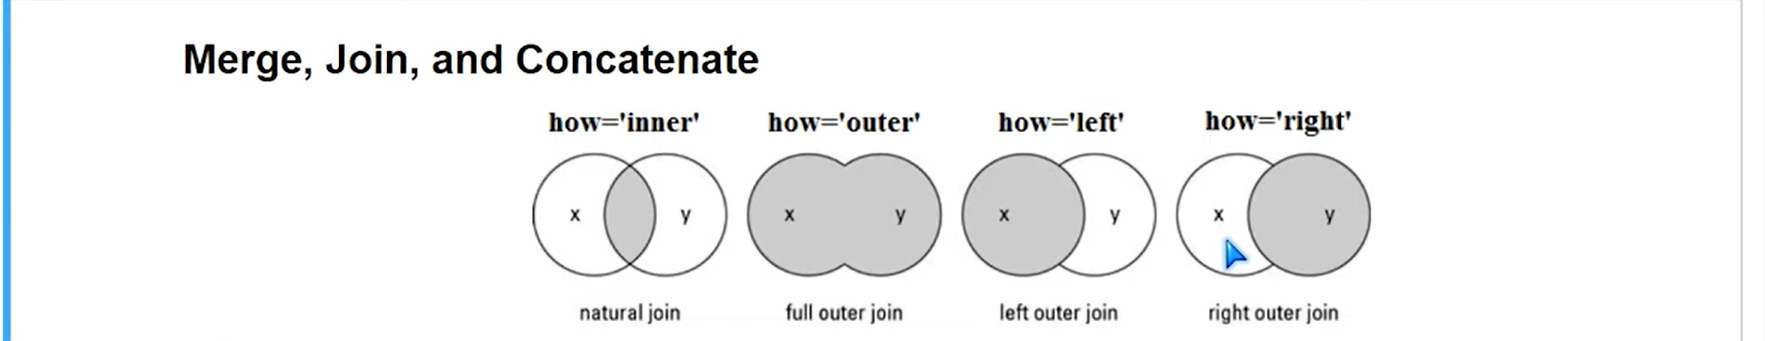


# Joins in Pandas 
Joins in Pandas allow you to combine two or more DataFrames based on a common key column. 
These joins are similar to SQL joins and are primarily used with the merge() function.\
1️⃣ Types of Joins in Pandas\
1. Inner Join\
Keeps only matching rows from both DataFrames.\
Non-matching rows are dropped.\
This is the default join in merge()\
Syntax: df_merged = df1.merge(df2, on='key', how='inner')

df1:
| key | A  |
|-----|----|
|  1  | X  |
|  2  | Y  |
|  3  | Z  |

df2:
| key | B  |
|-----|----|
|  2  | P  |
|  3  | Q  |
|  4  | R  |

Result (Inner Join):
| key | A  | B  |
|-----|----|----|
|  2  | Y  | P  |
|  3  | Z  | Q  |

2. Outer Join (Full Join)\
Includes all rows from both DataFrames.\
Missing values are filled with NaN.\
🔹 Example:\
Syntax: df_merged = df1.merge(df2, on='key', how='outer')

Result (Outer Join):
| key | A  | B  |
|-----|----|----|
|  1  | X  | NaN |
|  2  | Y  | P   |
|  3  | Z  | Q   |
|  4  | NaN | R  |

3. Left Join\
Keeps all rows from the left DataFrame.\
Only matching rows from the right are included.\
Unmatched rows from the right get NaN.

Synatx:df_merged = df1.merge(df2, on='key', how='left')

Result (Left Join):
| key | A  | B  |
|-----|----|----|
|  1  | X  | NaN |
|  2  | Y  | P   |
|  3  | Z  | Q   |

4. Right Join\
Keeps all rows from the right DataFrame.\
Only matching rows from the left are included.\
Unmatched rows from the left get NaN.\
Syntax: df_merged = df1.merge(df2, on='key', how='right')

Result (Right Join):

| key | A  | B  |
|-----|----|----|
|  2  | Y  | P  |
|  3  | Z  | Q  |
|  4  | NaN | R  |


# Index-Based Joins in Pandas
Index-based joins in Pandas are used to merge DataFrames based on their index values rather than a column. 
The primary method for performing such joins is the .join() method.

1️⃣ Using .join() for Index-Based Joins

The .join() method combines two DataFrames based on their index.\
It is faster than merge() when working with index-based data.\
Default join type: Left Join (how='left').\
You can change the join type using how ('left', 'right', 'inner', 'outer').

Syntax: df1.join(df2, how='type_of_join', lsuffix='_left', rsuffix='_right')

df1: Left DataFrame.\
df2: Right DataFrame.\
how: Type of join ('left', 'right', 'inner', 'outer').\
lsuffix, rsuffix: Adds suffixes when column names are the same.



In [30]:
# Examples of Index Based Joins
import pandas as pd

df1 = pd.DataFrame({'A': [10, 20, 30]}, index=['a', 'b', 'c'])
df2 = pd.DataFrame({'B': [100, 200, 300]}, index=['b', 'c', 'd'])

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)


DataFrame 1:
     A
a  10
b  20
c  30
DataFrame 2:
      B
b  100
c  200
d  300


In [35]:
# Performing Different Joins with .join() Method
# 1. Left Join (how='left')
# Keeps all index values from df1.
# Adds matching values from df2.
# Non-matching values are filled with NaN.

df1 = pd.DataFrame({'A': [10, 20, 30]}, index=['a', 'b', 'c'])
df2 = pd.DataFrame({'B': [100, 200, 300]}, index=['b', 'c', 'd'])

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
df_left = df1.join(df2, how='left')
print()
print("Result ",df_left)


DataFrame 1:
     A
a  10
b  20
c  30
DataFrame 2:
      B
b  100
c  200
d  300

Result      A      B
a  10    NaN
b  20  100.0
c  30  200.0


In [36]:
# 2. Right Join (how='right')
# Keeps all index values from df2.
# Adds matching values from df1.
# Non-matching values are filled with NaN.

df1 = pd.DataFrame({'A': [10, 20, 30]}, index=['a', 'b', 'c'])
df2 = pd.DataFrame({'B': [100, 200, 300]}, index=['b', 'c', 'd'])

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
df_right = df1.join(df2, how='right')
print()
print("Result ",df_right)



DataFrame 1:
     A
a  10
b  20
c  30
DataFrame 2:
      B
b  100
c  200
d  300

Result        A    B
b  20.0  100
c  30.0  200
d   NaN  300


In [37]:
# 3. Inner Join (how='inner')
# Keeps only the matching index values from both DataFrames.
df1 = pd.DataFrame({'A': [10, 20, 30]}, index=['a', 'b', 'c'])
df2 = pd.DataFrame({'B': [100, 200, 300]}, index=['b', 'c', 'd'])

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_inner = df1.join(df2, how='inner')
print("Result",df_inner)


DataFrame 1:
     A
a  10
b  20
c  30
DataFrame 2:
      B
b  100
c  200
d  300

Result     A    B
b  20  100
c  30  200


In [38]:
# 4. Outer Join (how='outer')
# Keeps all index values from both DataFrames.
# Non-matching values are filled with NaN.
df1 = pd.DataFrame({'A': [10, 20, 30]}, index=['a', 'b', 'c'])
df2 = pd.DataFrame({'B': [100, 200, 300]}, index=['b', 'c', 'd'])

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_outer = df1.join(df2, how='outer')
print("Result",df_outer)


DataFrame 1:
     A
a  10
b  20
c  30
DataFrame 2:
      B
b  100
c  200
d  300

Result       A      B
a  10.0    NaN
b  20.0  100.0
c  30.0  200.0
d   NaN  300.0


| Join Type | Description | Example Result |
|-----------|-------------|----------------|
| **Left Join** | Keeps all indices from `df1`, fills missing values with `NaN` | a → 10, NaN |
| **Right Join** | Keeps all indices from `df2`, fills missing values with `NaN` | d → NaN, 300 |
| **Inner Join** | Keeps only common indices | b → 20, 100 |
| **Outer Join** | Keeps all indices from both `df1` and `df2`, fills missing values with `NaN` | d → NaN, 300 |


# Concatenation in Pandas 

The .concat() method in Pandas is used to combine multiple DataFrames\
along a particular axis (rows or columns). Unlike .merge() or .join(), .concat() does not require a common key or index.

Syntax: pd.concat(objs, axis=0, join='outer', ignore_index=False, keys=None)\
Parameters:
objs: A list of DataFrames to concatenate.\
axis=0: Concatenates rows (default).\
axis=1: Concatenates columns.\
join: inner (keeps only common columns) or outer (keeps all columns).\
ignore_index=True: Ignores the index and resets it.\
keys: Creates a hierarchical index for tracking original DataFrames.


In [40]:
import pandas as pd

df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)


DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8


In [42]:
#3️⃣ Concatenation Methods
# 1. Concatenating by Rows (Default)


df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_concat = pd.concat([df1, df2])
print(df_concat)
# Rows are stacked from df1 and df2.
# Index remains unchanged.


DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

   A  B
0  1  3
1  2  4
0  5  7
1  6  8


In [43]:
# 2. Reset Index After Concatenation
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_reset = pd.concat([df1, df2], ignore_index=True)
print(df_reset)
# The index is reset after merging.

DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

   A  B
0  1  3
1  2  4
2  5  7
3  6  8


In [45]:
# 3. Concatenating by Columns (axis=1)
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_concat_col = pd.concat([df1, df2], axis=1)
print(df_concat_col)
# Columns are combined instead of rows

DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

   A  B  A  B
0  1  3  5  7
1  2  4  6  8


In [49]:
# 4. Concatenating DataFrames with Different Columns (join='outer')
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()

df3 = pd.DataFrame({'A': [9, 10], 'C': [11, 12]})
print(df3)
df_outer = pd.concat([df1, df3], join='outer', ignore_index=True)
print()
print("Result ",df_outer)
# Missing values (NaN) appear where columns do not match.


DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

    A   C
0   9  11
1  10  12

Result      A    B     C
0   1  3.0   NaN
1   2  4.0   NaN
2   9  NaN  11.0
3  10  NaN  12.0


In [50]:
# 5. Inner Join (join='inner')
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df3 = pd.DataFrame({'A': [9, 10], 'C': [11, 12]})
print(df3)
df_inner = pd.concat([df1, df3], join='inner', ignore_index=True)
print()
print(df_inner)
# Only common column (A) is kept.

DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

    A   C
0   9  11
1  10  12

    A
0   1
1   2
2   9
3  10


In [51]:
# 6. Using keys for Hierarchical Indexing
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})

print("DataFrame 1:\n", df1)
print("DataFrame 2:\n", df2)
print()
df_keys = pd.concat([df1, df2], keys=['df1', 'df2'])
print(df_keys)
# The keys label the original DataFrames.

DataFrame 1:
    A  B
0  1  3
1  2  4
DataFrame 2:
    A  B
0  5  7
1  6  8

       A  B
df1 0  1  3
    1  2  4
df2 0  5  7
    1  6  8


| Method | Description | Example Result |
|--------|-------------|----------------|
| **`pd.concat([df1, df2])`** | Default row-wise concatenation | Rows from `df2` are added below `df1` |
| **`pd.concat([df1, df2], axis=1)`** | Column-wise concatenation | `df2` columns are added to `df1` |
| **`pd.concat([df1, df3], join='outer')`** | Keeps all columns, fills missing values with `NaN` | A, B, and C appear with missing values |
| **`pd.concat([df1, df3], join='inner')`** | Keeps only common columns | Only column `A` remains |
| **`pd.concat([df1, df2], ignore_index=True)`** | Resets index after concatenation | Index is renumbered 0,1,2,... |
| **`pd.concat([df1, df2], keys=['df1', 'df2'])`** | Adds hierarchical index labels | Keeps track of original DataFrame source |


# Pivot Tables
Pivot Tables in Pandas\
A pivot table in Pandas is used to summarize, analyze, and reorganize data in a DataFrame.\
It allows you to group data based on a categorical column and apply aggregate functions like sum, mean, count, etc. on other numerical columns.

Syntax:  pd.pivot_table(data, values, index, columns, aggfunc, fill_value)

Parameters:
data: The DataFrame to pivot.\
values: The column(s) with numeric values to aggregate.\
index: The column(s) to group data by (rows).\
columns: The column(s) to pivot (create new columns).\
aggfunc: The aggregation function (sum, mean, count, etc.).\
fill_value: Value to replace missing values (NaN).

In [52]:
# 2️⃣ Example Dataset
import pandas as pd

data = {
    'Employee': ['Alice', 'Bob', 'Alice', 'Bob', 'Alice', 'Bob'],
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance'],
    'Salary': [50000, 55000, 60000, 62000, 70000, 72000],
    'Bonus': [5000, 7000, 6000, 8000, 10000, 12000]
}

df = pd.DataFrame(data)
print(df)


  Employee Department  Salary  Bonus
0    Alice         HR   50000   5000
1      Bob         HR   55000   7000
2    Alice         IT   60000   6000
3      Bob         IT   62000   8000
4    Alice    Finance   70000  10000
5      Bob    Finance   72000  12000


In [55]:
# 3️⃣ Creating Pivot Tables
# 1. Basic Pivot Table (Average Salary per Department)
print(df)
print()
pivot1 = pd.pivot_table(df, values='Salary', index='Department', aggfunc='mean')
print(pivot1)
# Groups employees by Department.
# Calculates the average Salary per department.

  Employee Department  Salary  Bonus
0    Alice         HR   50000   5000
1      Bob         HR   55000   7000
2    Alice         IT   60000   6000
3      Bob         IT   62000   8000
4    Alice    Finance   70000  10000
5      Bob    Finance   72000  12000

            Salary
Department        
Finance      71000
HR           52500
IT           61000


In [56]:
# 2. Pivot Table with Multiple Aggregations (sum & mean)
print(df)
print()
pivot2 = pd.pivot_table(df, values=['Salary', 'Bonus'], index='Department', aggfunc=['sum', 'mean'])
print(pivot2)
# sum and mean for both Salary and Bonus.

  Employee Department  Salary  Bonus
0    Alice         HR   50000   5000
1      Bob         HR   55000   7000
2    Alice         IT   60000   6000
3      Bob         IT   62000   8000
4    Alice    Finance   70000  10000
5      Bob    Finance   72000  12000

              sum           mean       
            Bonus  Salary  Bonus Salary
Department                             
Finance     22000  142000  11000  71000
HR          12000  105000   6000  52500
IT          14000  122000   7000  61000


In [62]:
# Pivot Table with Multiple Indexes
import pandas as pd

# Creating the DataFrame
data1= {
    'Region': ['North', 'North', 'North', 'North', 'South', 'South', 'South', 'South'],
    'Month': ['Jan', 'Jan', 'Feb', 'Feb', 'Jan', 'Jan', 'Feb', 'Feb'],
    'Product': ['Laptop', 'Mobile', 'Laptop', 'Mobile', 'Laptop', 'Mobile', 'Laptop', 'Mobile'],
    'Sales': [1000, 1500, 1100, 1600, 1200, 1400, 1300, 1550]
}

df = pd.DataFrame(data1)
print(df)
print()
# Creating the Pivot Table with Multiple Indexes
pivot_table = pd.pivot_table(df, values='Sales', index=['Region', 'Month'], columns=['Product'], aggfunc='sum')

print(pivot_table)
print()
# Example 2
import pandas as pd

# Creating the DataFrame
data2 = {
    'Date': ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
             '2024-01-06', '2024-01-07', '2024-01-08', '2024-01-09', '2024-01-10'],
    'Region': ['East', 'West', 'East', 'West', 'East', 'East', 'West', 'East', 'West', 'East'],
    'Category': ['Electronics', 'Electronics', 'Electronics', 'Furniture', 'Furniture',
                 'Electronics', 'Electronics', 'Furniture', 'Electronics', 'Furniture'],
    'Product': ['Laptop', 'Smartphone', 'Laptop', 'Sofa', 'Chair',
                'Tablet', 'Laptop', 'Table', 'Smartphone', 'Sofa'],
    'Sales ($)': [1500, 800, 1800, 1200, 400, 600, 1700, 900, 850, 1300]
}

df = pd.DataFrame(data2)
print(df)
# Creating Pivot Table with Multiple Indexes (Region & Category)
pivot_table = pd.pivot_table(df, values='Sales ($)', index=['Region', 'Category'], aggfunc='sum')

print(pivot_table)


  Region Month Product  Sales
0  North   Jan  Laptop   1000
1  North   Jan  Mobile   1500
2  North   Feb  Laptop   1100
3  North   Feb  Mobile   1600
4  South   Jan  Laptop   1200
5  South   Jan  Mobile   1400
6  South   Feb  Laptop   1300
7  South   Feb  Mobile   1550

Product       Laptop  Mobile
Region Month                
North  Feb      1100    1600
       Jan      1000    1500
South  Feb      1300    1550
       Jan      1200    1400

         Date Region     Category     Product  Sales ($)
0  2024-01-01   East  Electronics      Laptop       1500
1  2024-01-02   West  Electronics  Smartphone        800
2  2024-01-03   East  Electronics      Laptop       1800
3  2024-01-04   West    Furniture        Sofa       1200
4  2024-01-05   East    Furniture       Chair        400
5  2024-01-06   East  Electronics      Tablet        600
6  2024-01-07   West  Electronics      Laptop       1700
7  2024-01-08   East    Furniture       Table        900
8  2024-01-09   West  Electronics  Smartp

In [61]:
# 4. Pivot Table with Columns Parameter
import pandas as pd

# Creating the DataFrame
data = {
    'Department': ['IT', 'IT', 'IT', 'HR', 'HR', 'HR', 'Sales', 'Sales'],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Salary': [70000, 68000, 75000, 65000, 72000, 64000, 62000, 60000]
}

df = pd.DataFrame(data)
print(df)
print()
# Creating a Pivot Table with 'Gender' in columns
pivot_table = pd.pivot_table(df, values='Salary', index='Department', columns='Gender', aggfunc='mean')

print(pivot_table
#  How to Read This Table?
# ✅ Rows (index=Department) → Shows different departments (IT, HR, Sales).
# ✅ Columns (columns=Gender) → Splits salary data into Male and Female categories.
# ✅ Values (values=Salary) → Represents the average salary for each department, grouped by Gender.

# 💡 For Example:

# In IT, the average salary is ₹68,000 for Females and ₹72,500 for Males.
# In HR, the average salary is ₹64,500 for Females and ₹72,000 for Males.
# In Sales, the average salary is ₹60,000 for Females and ₹62,000 for Males

  Department  Gender  Salary
0         IT    Male   70000
1         IT  Female   68000
2         IT    Male   75000
3         HR  Female   65000
4         HR    Male   72000
5         HR  Female   64000
6      Sales    Male   62000
7      Sales  Female   60000

Gender      Female   Male
Department               
HR           64500  72000
IT           68000  72500
Sales        60000  62000


#  Working with Time Series Data 
📌 Working with Time Series Data in Pandas
Time series data is a sequence of data points indexed by time (timestamps, dates, or periods).\
Pandas provides powerful tools to work with time-based data, such as indexing, resampling, shifting, and visualization.

In [74]:
# 📌 Step 1: Creating Time Series Data
# 1️⃣ Creating a DateTime Index
# We can convert a column to datetime format and set it as an index.
import pandas as pd

# Creating a sample time series dataset
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Sales': [100, 150, 200, 250, 300, 275, 350, 400, 450, 500]
}

df = pd.DataFrame(data)
print(df)
df.set_index('Date', inplace=True)

print(df)
# 📌 Step 2: Accessing Time Series Data
# 2️⃣ Selecting Data by Date
print()
print(f"sale on {'2024-01-05'} this date is :",df.loc['2024-01-05'])  # Get sales for a specific date

# 3️⃣ Filtering Data by Date Range
print()
print(f"Sales between {'2024-01-01'} to {'2024-01-10'} is: \n",df.loc['2024-01-03':'2024-01-07'])

# 📌 Step 3: Resampling Data
# 4️⃣ Changing Frequency (Resampling)
# 🔹 Aggregating to Weekly Sales:
weekly_sales = df.resample('W').sum()
print("weekly Sales: ")
print(weekly_sales)
# ✅ Resampling changes the time frequency and aggregates data (sum, mean, count, etc.).



        Date  Sales
0 2024-01-01    100
1 2024-01-02    150
2 2024-01-03    200
3 2024-01-04    250
4 2024-01-05    300
5 2024-01-06    275
6 2024-01-07    350
7 2024-01-08    400
8 2024-01-09    450
9 2024-01-10    500
            Sales
Date             
2024-01-01    100
2024-01-02    150
2024-01-03    200
2024-01-04    250
2024-01-05    300
2024-01-06    275
2024-01-07    350
2024-01-08    400
2024-01-09    450
2024-01-10    500

sale on 2024-01-05 this date is : Sales    300
Name: 2024-01-05 00:00:00, dtype: int64

Sales between 2024-01-01 to 2024-01-10 is: 
             Sales
Date             
2024-01-03    200
2024-01-04    250
2024-01-05    300
2024-01-06    275
2024-01-07    350
weekly Sales: 
            Sales
Date             
2024-01-07   1625
2024-01-14   1350


In [76]:
# 📌 Step 4: Handling Missing Dates
# 5️⃣ Creating a Time Series with Missing Dates
data = {
    'Date': ['2024-01-01', '2024-01-03', '2024-01-07', '2024-01-10'],
    'Sales': [100, 200, 350, 500]
}

df_missing = pd.DataFrame(data)
print(df_missing)
df_missing['Date'] = pd.to_datetime(df_missing['Date'])
df_missing.set_index('Date', inplace=True)# Reindexing 

print(df_missing)
# 🔹 Output: (Notice missing dates: 2nd, 4th-6th, 8th-9th)
# ✅ To handle missing dates, we can reindex and fill missing values.

# 6️⃣ Filling Missing Dates
df_filled = df_missing.asfreq('D', method='ffill')
print(df_filled)

# ✅ Missing dates are now filled using the last available value (Forward Fill).



         Date  Sales
0  2024-01-01    100
1  2024-01-03    200
2  2024-01-07    350
3  2024-01-10    500
            Sales
Date             
2024-01-01    100
2024-01-03    200
2024-01-07    350
2024-01-10    500
            Sales
Date             
2024-01-01    100
2024-01-02    100
2024-01-03    200
2024-01-04    200
2024-01-05    200
2024-01-06    200
2024-01-07    350
2024-01-08    350
2024-01-09    350
2024-01-10    500


In [77]:
# 📌 Step 5: Shifting & Rolling Window Operations
# 7️⃣ Shifting Data
# 🔹 Shifting sales forward (Future Prediction Simulation)
df['Sales_Next_Day'] = df['Sales'].shift(-1)
print(df)

# ✅ Shifting helps in comparing current vs next day's sales.



            Sales  Sales_Next_Day
Date                             
2024-01-01    100           150.0
2024-01-02    150           200.0
2024-01-03    200           250.0
2024-01-04    250           300.0
2024-01-05    300           275.0
2024-01-06    275           350.0
2024-01-07    350           400.0
2024-01-08    400           450.0
2024-01-09    450           500.0
2024-01-10    500             NaN


            Sales  Sales_Next_Day    7-Day MA
Date                                         
2024-01-01    100           150.0         NaN
2024-01-02    150           200.0         NaN
2024-01-03    200           250.0  150.000000
2024-01-04    250           300.0  200.000000
2024-01-05    300           275.0  250.000000
2024-01-06    275           350.0  275.000000
2024-01-07    350           400.0  308.333333
2024-01-08    400           450.0  341.666667
2024-01-09    450           500.0  400.000000
2024-01-10    500             NaN  450.000000


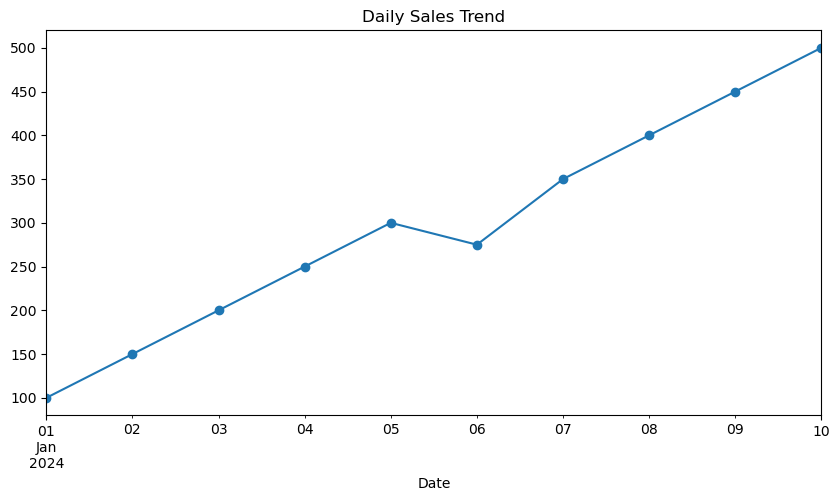

In [79]:
# 8️⃣ Rolling Window (Moving Average)
# 🔹 7-day moving average for smoother trends

df['7-Day MA'] = df['Sales'].rolling(window=3).mean()
print(df)

# 📌 Step 6: Time Series Visualization
import matplotlib.pyplot as plt

df['Sales'].plot(title="Daily Sales Trend", figsize=(10, 5), marker='o', linestyle='-')
plt.show()


In [ ]:
# 🎯 Key Takeaways:

# Pandas makes working with time series data simple.
# Resampling helps change time frequency.
# Shifting and rolling windows analyze trends & patterns.
# Handling missing dates ensures complete datasets.
# Visualization is useful for insights.

In [ ]:
# Forecasting Techniques with Pandas 
# See it later 

In [82]:
#  Exporting Data 
# 📤 Exporting Data in Pandas
# Exporting data in Pandas means saving a DataFrame into different file formats 
# like CSV, Excel, JSON, SQL, and more so that it can be used outside of Python.


import pandas as pd

# Create a sample DataFrame
data = {
    "Product_ID": [101, 102, 103, 104, 105],
    "Product_Name": ["Laptop", "Smartphone", "Tablet", "Headphones", "Smartwatch"],
    "Category": ["Electronics", "Electronics", "Electronics", "Accessories", "Accessories"],
    "Price": [800, 500, 300, 150, 200],
    "Stock": [50, 100, 75, 200, 120]
}

df = pd.DataFrame(data)
print(df)

#1️⃣ Export to CSV(Comma-Separated Values)
df.to_csv("products.csv", index=False)

#2️⃣ Export to Excel
df.to_excel("products.xlsx", index=False, sheet_name="Products")

#3️⃣ Export to JSON
df.to_json("products.json", orient="records")

#4️⃣ Export to SQL
from sqlalchemy import create_engine

engine = create_engine("sqlite:///products.db")  # SQLite database
df.to_sql("products_table", con=engine, if_exists="replace", index=False)

#5️⃣ Export to Pickle
df.to_pickle("products.pkl")

#Export to HTML
df.to_html("products.html")



   Product_ID Product_Name     Category  Price  Stock
0         101       Laptop  Electronics    800     50
1         102   Smartphone  Electronics    500    100
2         103       Tablet  Electronics    300     75
3         104   Headphones  Accessories    150    200
4         105   Smartwatch  Accessories    200    120
